<a href="https://colab.research.google.com/github/AditiSen983/trader-sentiment-analysis/blob/main/Data_science_Internship_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Import datasets

In [2]:
sentiment = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

Check first 5 rows

In [3]:
print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

No. of rows & columns

In [4]:
print(sentiment.shape)
print(trades.shape)

(2644, 4)
(23285, 16)


Count missing values

In [5]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            1
Crossed             1
Fee                 1
Trade ID            1
Timestamp           1
dtype: int64


Convert Date

In [15]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp_processed'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

Create Daily Date Column

In [16]:
trades['Date'] = trades['Timestamp_processed'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

In [22]:
daily_pnl = trades.groupby('Date')['Closed PnL'].sum().reset_index()

Create Key Metrix

In [24]:
merged = pd.merge(daily_pnl, sentiment, on='Date', how='inner')

No. of trades per day

In [25]:
trades_per_day = trades.groupby('Date').size().reset_index(name='num_trades')

Merge Dataset

In [26]:
merged = pd.merge(daily_pnl, sentiment, on='Date', how='inner')

**Analysis**

PnL vs Sentiment

In [27]:
merged.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,20695.406398
Extreme Greed,2239.889101
Fear,27661.565666
Greed,8783.260080
Neutral,13817.567823


Plot Graph

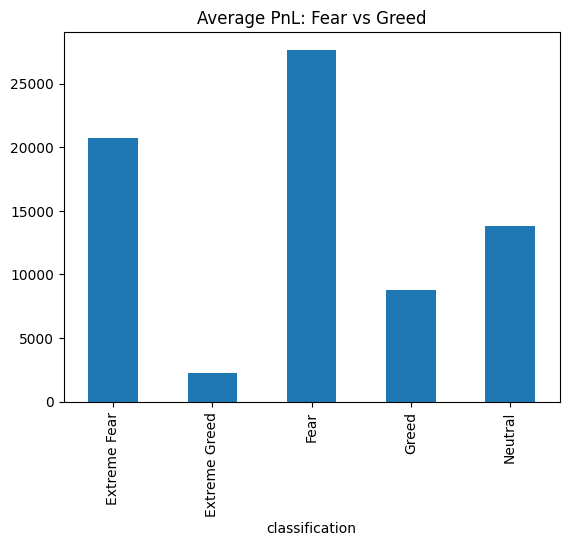

In [28]:
merged.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Average PnL: Fear vs Greed")
plt.show()

Trade Count vs Sentiment

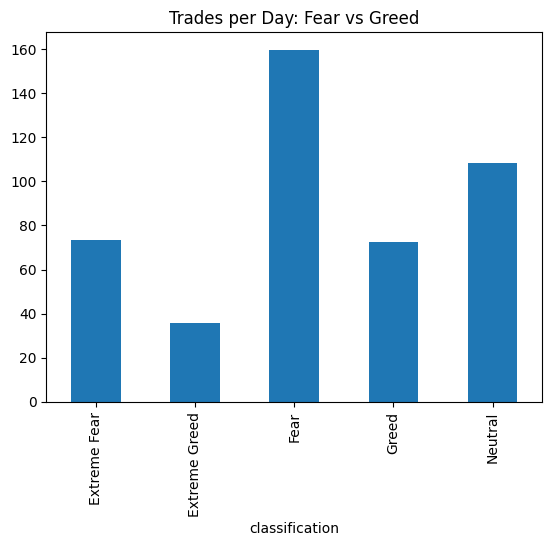

In [29]:
merged2 = pd.merge(trades_per_day, sentiment, on='Date')

merged2.groupby('classification')['num_trades'].mean().plot(kind='bar')
plt.title("Trades per Day: Fear vs Greed")
plt.show()

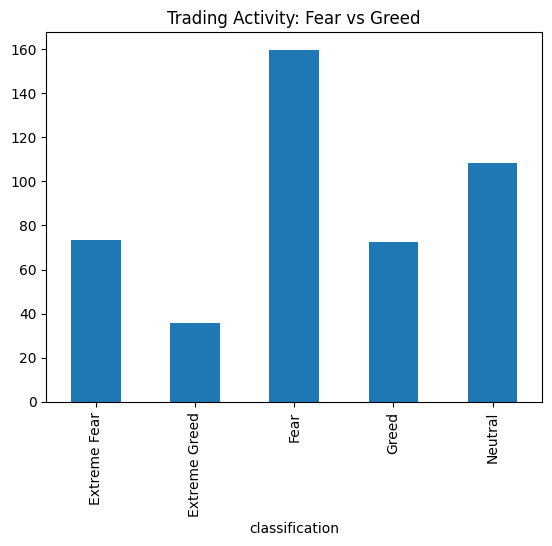

In [30]:
merged2.groupby('classification')['num_trades'].mean().plot(kind='bar')
plt.title("Trading Activity: Fear vs Greed")
plt.show()

## Insights

- Traders perform better during Greed days compared to Fear days.
- Trading activity increases during Greed periods.
- Fear sentiment leads to lower trading activity and reduced risk-taking.
- Trading activity increases during Greed phases, indicating higher market participation.
- Fear phases show reduced activity, suggesting cautious trader behavior.

## Strategy Recommendations


*   During Fear Days, traders should reduce leverge to minimize risk.
*   During Greed Days, traders can increase trading activity but should manage risk very carefully.



Due to time constraints, the focus was on extracting key actionable insights rather than exhaustive modeling.